In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CUBA_LIF_layer import CUBA_LIF_Layer
from LIF_Sequential_layer import LIFSequential
from encoding.rate_coding import RateEncoding
from scipy.optimize import curve_fit
from aquarel import load_theme

In [2]:
coeff = 3.5
def f(x, a):

    return a * x

In [3]:
datas = np.arange(1, 101, 1)
datas.shape

(100,)

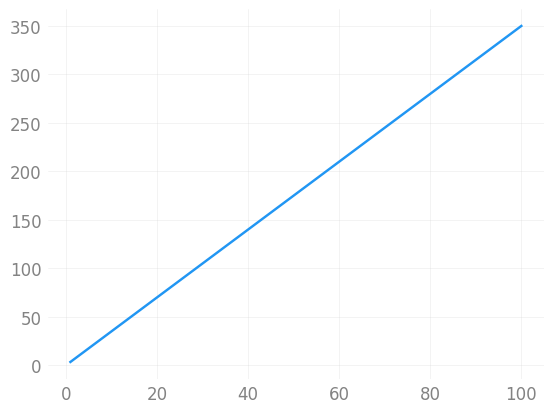

In [4]:
with load_theme("ambivalent").set_transforms(trim=True):
    plt.figure()
    plt.plot(datas, f(datas, coeff))
    plt.show()

In [5]:
# Encode datas using Latency coding (Time-to-First-Spike)
def ttfs_encode(data, t_start, t_end):
    return np.round(t_start + (t_end - t_start) * ((np.max(data) - data) / (np.max(data) - np.min(data)))).astype(int)

target_times_input = ttfs_encode(datas, 5, 400)
target_times_output = ttfs_encode(f(datas, coeff), 5, 400)

input_spikes = np.zeros((100, 500))
input_spikes[np.arange(100), target_times_input] = 1

In [6]:
cuba_lif_model = CUBA_LIF_Layer(1, 1)

In [8]:
epochs = 100
eta = 0.1
cuba_lif_model.reset()

for epoch in range(epochs):
    for data in range(len(target_times_input)):

        for i in range(500):

            cuba_lif_model.forward(input_spikes[data, i])

            if cuba_lif_model.spikes[0]:

                error = i - target_times_output[data]
                delta_w = -1 * eta * 1 * error
                cuba_lif_model.weight += delta_w
                print(f"Delta weight: {delta_w}")
                break

        #print(f"Epoch: {epoch}, New weight: {cuba_lif_model.weight}")
        cuba_lif_model.reset()

Epoch: 99, Poids fin de boucle: [[2.5]]
